In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

from utility.assets import simulate_correlated_gbm

In [2]:
k = 3
corr = np.array([
    [1.0, 0.6, -0.2],
    [0.6, 1.0, 0.4],
    [-0.2, 0.4, 1.0],
])

S0 = np.array([10, 5, 3])
sigma = np.array([0.2, 0.3, 0.25])
r = 0.05
T = 1.0
N = 252
n_paths = 100000
seed = 42

In [3]:
def test(S0, r, sigma, corr, T=1.0, N=252, n_paths=100, save_path=None, seed=None):
    S = simulate_correlated_gbm(S0, r, sigma, corr, T, N, n_paths, seed)
    S_product = np.prod(S, axis=2)
    S_final = S_product[:, -1]

    # reduce to 1D case
    k = S0.shape[0]
    cov_matrix = corr * np.outer(sigma, sigma)
    S0_1d = np.prod(S0)
    r_1d = r * k + np.sum(np.tril(cov_matrix, k=-1))
    sigma_1d = np.sqrt(np.sum(cov_matrix))
    corr_1d = np.array([[1.0]])

    S_1d = simulate_correlated_gbm([S0_1d], [r_1d], [sigma_1d], corr_1d, T, N, n_paths, seed)
    S_product_1d = S_1d[:, :, 0]
    S_final_1d = S_product_1d[:, -1]

    # ks test on S_product and S_product_1d
    ks_stat, p_value = ks_2samp(S_final, S_final_1d)
    print(f"KS Statistic: {ks_stat}, P-value: {p_value}")

    max_final_price = 1000
    S_final = S_final[S_final < max_final_price]
    S_final_1d = S_final_1d[S_final_1d < max_final_price]

    plt.figure(figsize=(8, 5))
    plt.hist(S_final, bins=100, alpha=0.5, label='Multi-asset Price', color='blue', density=True)
    plt.hist(S_final_1d, bins=100, alpha=0.5, label='1D Price', color='green', density=True)
    plt.title('Histogram of Final Prices')
    plt.xlabel('Final Price')
    plt.ylabel('Density')
    plt.legend()
    
    if save_path:
        plt.savefig(save_path)
    plt.show()

KS Statistic: 0.00273000000000001, P-value: 0.8491282739238893


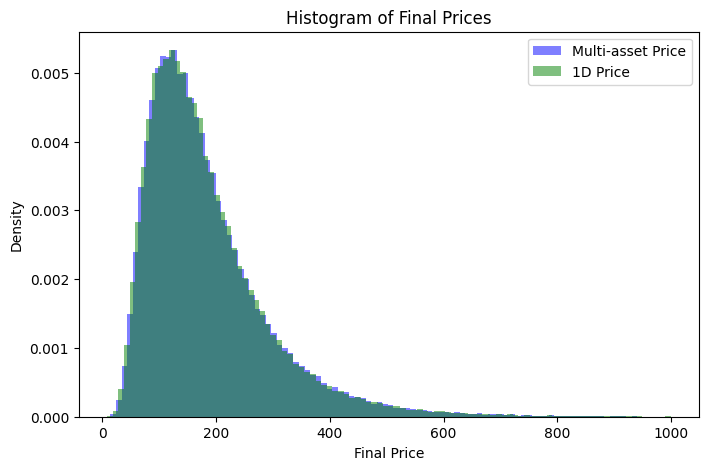

In [4]:
test(S0, r, sigma, corr, T, N, n_paths, save_path='../../plots/black_scholes/gbm_histogram.png', seed=seed)